Ejercicio 2.

a) La curva elegida es de grado 3 con: P0 = (0,0), P1 = (3.5, -2.9), P2 = (10.6, 7), P3 = (12, 0)

Curvas a evaluar: 7623

Primera búsqueda:
P1 = [ 3. -3.]
P2 = [11.  7.]
Longitud = 14.340165098714483
Curvas a evaluar: 14641

RESULTADO FINAL
Grado n = 3
P0 = [0. 0.]
P1 = [ 3.5 -2.9]
P2 = [10.6  7. ]
P3 = [12.  0.]
Longitud aproximada FINAL = 14.2708

Archivo para bezier_to_svg.py:
[[0, 0, np.float64(3.5), np.float64(-2.9), np.float64(10.6), np.float64(7.0), 12, 0]]


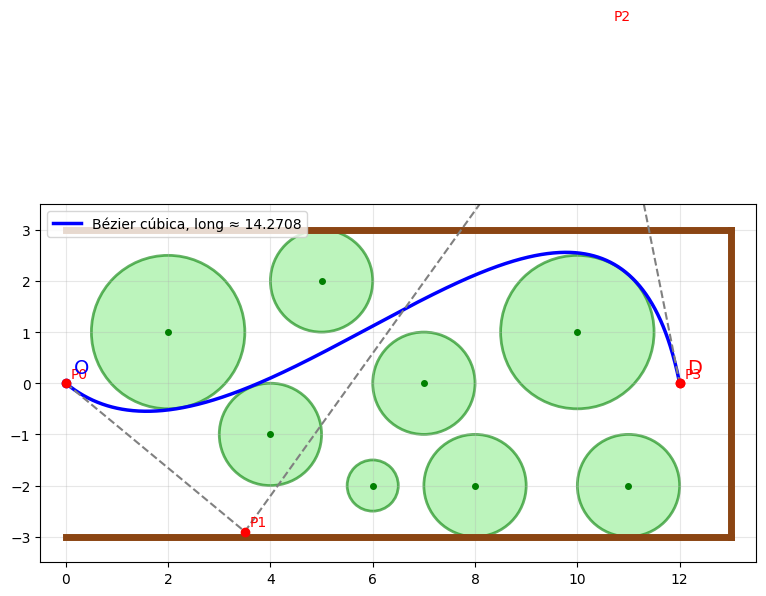

In [29]:
## b) y c)


import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

ORIGIN = np.array([0, 0], dtype=float)
DEST = np.array([12, 0], dtype=float)

BUSHES = [
    (2,  1,  1.5),
    (4, -1,  1.0),
    (5,  2,  1.0),
    (7,  0,  1.0),
    (8, -2,  1.0),
    (6, -2,  0.5),
    (10, 1,  1.5),
    (11,-2,  1.0),
]

def bezier_cubica(P0, P1, P2, P3, ts):
    u = 1 - ts
    return (
        (u**3)[:, None] * P0 +
        (3*u**2*ts)[:, None] * P1 +
        (3*u*ts**2)[:, None] * P2 +
        (ts**3)[:, None] * P3
    )

def longitud_curva(curva):
    diffs = np.diff(curva, axis=0)
    return np.sum(np.linalg.norm(diffs, axis=1))

def choca(curva):
    x = curva[:, 0]
    y = curva[:, 1]

    if np.any(y >= 3) or np.any(y <= -3) or np.any(x >= 13):
        return True

    for cx, cy, r in BUSHES:
        if np.any((x - cx)**2 + (y - cy)**2 <= r**2):
            return True

    return False

def buscar_cubica_fb(r1x, r1y, r2x, r2y, paso):
    mejor_longitud = np.inf
    mejor_P1 = None
    mejor_P2 = None

    ts = np.linspace(0, 1, 250)

    xs1 = np.arange(r1x[0], r1x[1] + 1e-9, paso)
    ys1 = np.arange(r1y[0], r1y[1] + 1e-9, paso)
    xs2 = np.arange(r2x[0], r2x[1] + 1e-9, paso)
    ys2 = np.arange(r2y[0], r2y[1] + 1e-9, paso)

    total = len(xs1) * len(ys1) * len(xs2) * len(ys2)
    print("Curvas a evaluar:", total)

    for p1x in xs1:
        for p1y in ys1:
            for p2x in xs2:
                for p2y in ys2:
                    P1 = np.array([p1x, p1y])
                    P2 = np.array([p2x, p2y])

                    curva = bezier_cubica(ORIGIN, P1, P2, DEST, ts)

                    if not choca(curva):
                        long = longitud_curva(curva)

                        if long < mejor_longitud:
                            mejor_longitud = long
                            mejor_P1 = P1.copy()
                            mejor_P2 = P2.copy()

    return mejor_P1, mejor_P2, mejor_longitud

# =========================================================
# PRIMERA BÚSQUEDA, PASO 0.5
# =========================================================

P1, P2, long = buscar_cubica_fb(
    r1x=(2, 5),
    r1y=(-5, -1),
    r2x=(8, 13),
    r2y=(4, 9),
    paso=0.5
)

if P1 is None:
    raise RuntimeError("No se encontró curva válida en la primera búsqueda.")

print("\nPrimera búsqueda:")
print("P1 =", P1)
print("P2 =", P2)
print("Longitud =", long)

# =========================================================
# SEGUNDA BÚSQUEDA, PASO 0.1
# =========================================================

P1, P2, long = buscar_cubica_fb(
    r1x=(P1[0]-0.5, P1[0]+0.5),
    r1y=(P1[1]-0.5, P1[1]+0.5),
    r2x=(P2[0]-0.5, P2[0]+0.5),
    r2y=(P2[1]-0.5, P2[1]+0.5),
    paso=0.1
)

if P1 is None:
    raise RuntimeError("No se encontró curva válida en la segunda búsqueda.")

P1 = np.round(P1, 1)
P2 = np.round(P2, 1)

ts = np.linspace(0, 1, 1000)
curva = bezier_cubica(ORIGIN, P1, P2, DEST, ts)
long = longitud_curva(curva)

print("\nRESULTADO FINAL")
print("Grado n = 3")
print("P0 =", ORIGIN)
print("P1 =", P1)
print("P2 =", P2)
print("P3 =", DEST)
print("Longitud aproximada FINAL =", round(long, 4))

print("\nArchivo para bezier_to_svg.py:")
print([[0, 0, P1[0], P1[1], P2[0], P2[1], 12, 0]])

# =========================================================
# GRÁFICO
# =========================================================

fig, ax = plt.subplots(figsize=(14, 7))
ax.set_aspect("equal")
ax.set_xlim(-0.5, 13.5)
ax.set_ylim(-3.5, 3.5)
ax.grid(True, alpha=0.3)

# Paredes
ax.plot([0, 13], [3, 3], color="saddlebrown", linewidth=5)
ax.plot([0, 13], [-3, -3], color="saddlebrown", linewidth=5)
ax.plot([13, 13], [-3, 3], color="saddlebrown", linewidth=5)

# Arbustos
for cx, cy, r in BUSHES:
    ax.add_patch(
        Circle(
            (cx, cy),
            r,
            facecolor="lightgreen",
            edgecolor="green",
            alpha=0.6,
            linewidth=2
        )
    )
    ax.plot(cx, cy, "go", markersize=4)

# Curva
ax.plot(
    curva[:, 0],
    curva[:, 1],
    "b",
    linewidth=2.5,
    label=f"Bézier cúbica, long ≈ {long:.4f}"
)

# Puntos de control
pts = np.array([ORIGIN, P1, P2, DEST])

ax.plot(
    pts[:, 0],
    pts[:, 1],
    "--",
    color="gray"
)

ax.scatter(
    pts[:, 0],
    pts[:, 1],
    color="red",
    zorder=5
)

for i, p in enumerate(pts):
    ax.text(
        p[0] + 0.1,
        p[1] + 0.1,
        f"P{i}",
        color="red"
    )

# Origen y destino
ax.plot(*ORIGIN, "bo")
ax.text(0.15, 0.2, "O", color="blue", fontsize=14)

ax.plot(*DEST, "ro")
ax.text(12.15, 0.2, "D", color="red", fontsize=14)

ax.legend()
plt.tight_layout()
plt.show()


In [23]:
# =========================================================
# EXPORTACIÓN PARA bezier_to_svg.py
# =========================================================
nombre_archivo = "puntos_optimos.txt"
datos_svg = [[0.0, 0.0, 3.5, -2.9, 10.6, 7, 12, 0.0]]

with open(nombre_archivo, "w") as f:
    f.write(str(datos_svg))

print(f"\n✅ Archivo '{nombre_archivo}' generado con éxito.")
print(f"Para generar el SVG, ejecuta en tu terminal:")
print(f"python bezier_to_svg.py {nombre_archivo} salida.svg --mostrar-controles")


✅ Archivo 'puntos_optimos.txt' generado con éxito.
Para generar el SVG, ejecuta en tu terminal:
python bezier_to_svg.py puntos_optimos.txt salida.svg --mostrar-controles


In [27]:
!python bezier_to_svg.py puntos_hardcoded.txt --mostrar-controles

Traceback (most recent call last):
  File "c:\Users\julik\OneDrive\Escritorio\ejercicios\ejercicio_2\bezier_to_svg.py", line 265, in <module>
    main()
    ~~~~^^
  File "c:\Users\julik\OneDrive\Escritorio\ejercicios\ejercicio_2\bezier_to_svg.py", line 252, in main
    pts = load_control_points(input_path)
  File "c:\Users\julik\OneDrive\Escritorio\ejercicios\ejercicio_2\bezier_to_svg.py", line 53, in load_control_points
    with open(path) as f:
         ~~~~^^^^^^
FileNotFoundError: [Errno 2] No such file or directory: 'puntos_hardcoded.txt'


In [25]:
import pprint

with open("puntos_optimos.txt","w") as f:
    pprint.pprint(datos_svg, stream=f)

In [30]:
!python bezier_to_svg.py puntos_hardcoded.txt --mostrar-controles

Curva de Bézier de grado 3 (4 puntos de control) cargada desde 'puntos_hardcoded.txt'.
SVG guardado en 'puntos_hardcoded.svg'.
